## Setup

In [ ]:
!pip install biopython --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from tqdm import tqdm
import re
from pathlib import Path
from pprint import pprint
from Bio import SeqIO
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

In [ ]:
#===========================
# CREATE OUTPUT PATH
#===========================
eastern = pytz.timezone('America/New_York')
run_date = datetime.now(eastern).strftime("%Y-%m-%d")
output_dir = Path("filtered_outputs") / run_date
output_dir.mkdir(exist_ok=True,parents=True)

# VARIABLES (CHANGE THIS CELL)

In [ ]:
#============================
# EXCEL FILE WITH IDS COLUMNS
#============================
xlx_file = "fard.xlsx"
column_name = "transcript"


#===========================
# PROTEOME(FASTA) FILE NAME
#===========================
proteome_file = "Dverticillatus_isoseq_cd98.fa.transdecoder.pep"


#==================================
# LOADING FILES (DONT CHANGE BELOW)
#==================================
proteome_records : list[SeqIO.SeqRecord] = list(SeqIO.parse(proteome_file, "fasta"))
print(f"Total number of protein sequences in the proteome: {len(proteome_records):,}")

df = pd.read_excel(xlx_file)
protein_ids = set(df[column_name][df[column_name].notnull()])

print(f"Total unique <{column_name}> IDs in Excel: {len(protein_ids):,}")


Total number of protein sequences in the proteome: 147,218
Total unique <transcript> IDs in Excel: 3,964


## Visualize

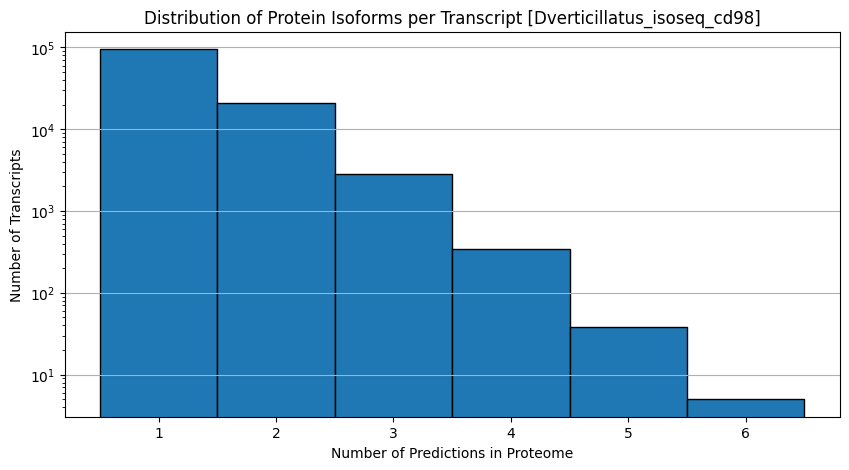

In [ ]:
#===========================
# VISUALIZE PROTEOME
#===========================
def visualize_proteome(records,file_name):

  protein_hist = {}
  for record in records:


      name = record.id.split(".p")[0].strip()
      protein_hist[name] = protein_hist.get(name, 0) + 1

  plt.figure(figsize=(10, 5))
  plt.hist(protein_hist.values(), bins=range(1, max(protein_hist.values()) + 2), align='left', edgecolor='black')
  plt.title(f'Distribution of Protein Isoforms per Transcript [{file_name.split(".")[0]}]')
  plt.xlabel('Number of Predictions in Proteome')
  plt.ylabel('Number of Transcripts')
  plt.yscale('log')
  plt.xticks(range(1, max(protein_hist.values()) + 1))
  plt.grid(axis='y')

  plt.show()

visualize_proteome(proteome_records, proteome_file)

# Match Finding Records

In [ ]:
#==============================
# FILTER FASTA USING ID COLUMN
#==============================

matched_records : list[SeqIO.SeqRecord] = []
pbar1 = tqdm(
    enumerate(proteome_records),
    desc=f"Enumerating {proteome_file}",
    total=len(proteome_records)
    )
count_set = set()
# Loop over Fasta File
for i,record in pbar1:

    name = record.id.strip().split(".p")[0] # Keep left of '.p*' postfix


    # If name appears in the set of unique ids in the excel doc: append
    if(name and (name in protein_ids)):
        matched_records.append(record)

        if name not in count_set:
            count_set.add(name)


    # Update progress details every 500 iterations
    if i>=500 and i%500==0:
        pbar1.set_postfix({"Current RNA":name,"Total Found":len(matched_records)})


print(f"\nFound {len(matched_records)} sequences matching {len(count_set)} out of {len(protein_ids)} given IDs")
print(f"\nThere are {len(matched_records)} records in the truncated proteome")

Enumerating Dverticillatus_isoseq_cd98.fa.transdecoder.pep: 100%|██████████| 147218/147218 [00:01<00:00, 138475.84it/s, Current RNA=transcript/99544, Total Found=4371]


Found 4382 sequences matching 3528 out of 3964 given IDs

There are 4382 records in the truncated proteome


In [ ]:
#=============================
# SAVE RESULTS TO OUTPUT PATH
#=============================
timestamp = datetime.now(eastern).strftime("%H-%M-%S")
output_filename = f"filtered_{proteome_file}_{timestamp}.fasta"

SeqIO.write(matched_records, output_dir / output_filename, "fasta")

print(f"Saved filtered sequences to {output_filename}")

Saved filtered sequences to filtered_Dverticillatus_isoseq_cd98.fa.transdecoder.pep_13-10-27.fasta


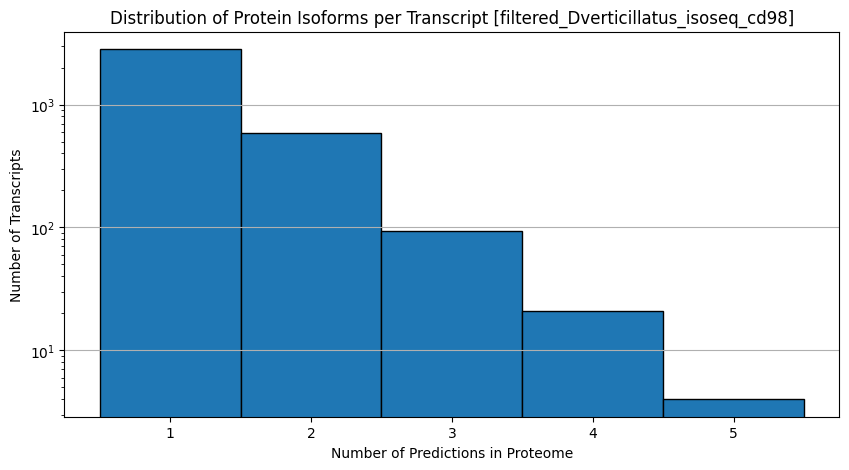

In [ ]:
#============================
# VISUALIZE FILTERED PROTEOME
#============================
visualize_proteome(matched_records,output_filename)